In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("debt_data.csv")
df.head()

,Country Name,1995,1996,1997,1998,1999,2000,2001,2002,2003,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
0,Aruba,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Africa Western and Central,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Angola,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df = df.dropna(how='all')

df.head()

,Country Name,1995,1996,1997,1998,1999,2000,2001,2002,2003,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
0,Aruba,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Africa Western and Central,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Angola,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df_long = df.melt(id_vars=["Country Name"], 
                  var_name="Year", 
                  value_name="Debt")

df_long.head()

,Country Name,Year,Debt
0,Aruba,1995,NaN
1,Africa Eastern and Southern,1995,NaN
2,Afghanistan,1995,NaN
3,Africa Western and Central,1995,NaN
4,Angola,1995,NaN


In [5]:
df_long = df_long.dropna()

df_long.head()

,Country Name,Year,Debt
5,Albania,1995,35.756904
13,Australia,1995,21.681807
16,Burundi,1995,128.919219
17,Belgium,1995,125.576591
22,Bahrain,1995,16.986452


In [6]:
df_long["Year"] = df_long["Year"].astype(int)

df_long.info()

<class 'pandas.DataFrame'>
Index: 1687 entries, 5 to 6914
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Name  1687 non-null   str    
 1   Year          1687 non-null   int64  
 2   Debt          1687 non-null   float64
dtypes: float64(1), int64(1), str(1)
memory usage: 52.7 KB


In [7]:
df_long.isnull().sum()

Country Name    0
Year            0
Debt            0
dtype: int64

In [8]:
top_countries = df_long.groupby("Country Name")["Debt"].sum().sort_values(ascending=False)

top_countries.head(10)

Country Name
Japan                        3709.077907
Greece                       3643.917528
United Kingdom               3074.445376
Jamaica                      2824.978213
Belgium                      2755.743297
Singapore                    2567.057201
Iceland                      2411.631997
Post-demographic dividend    2110.603397
High income                  2102.799607
OECD members                 2074.153863
Name: Debt, dtype: float64

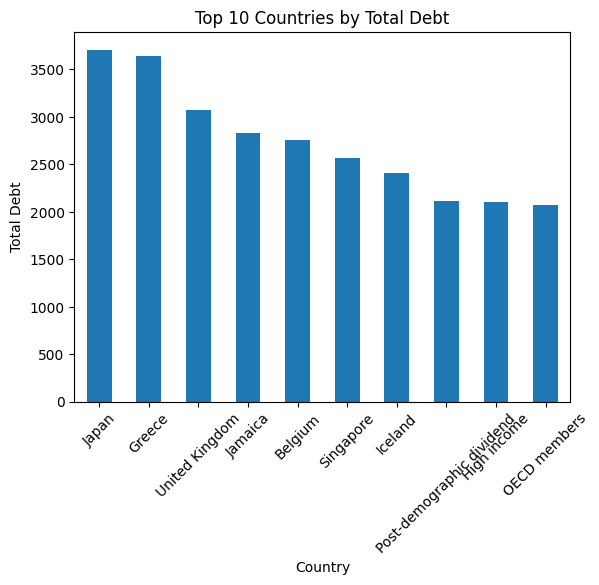

In [9]:
top_countries.head(10).plot(kind='bar')

plt.title("Top 10 Countries by Total Debt")
plt.xlabel("Country")
plt.ylabel("Total Debt")
plt.xticks(rotation=45)

plt.show()

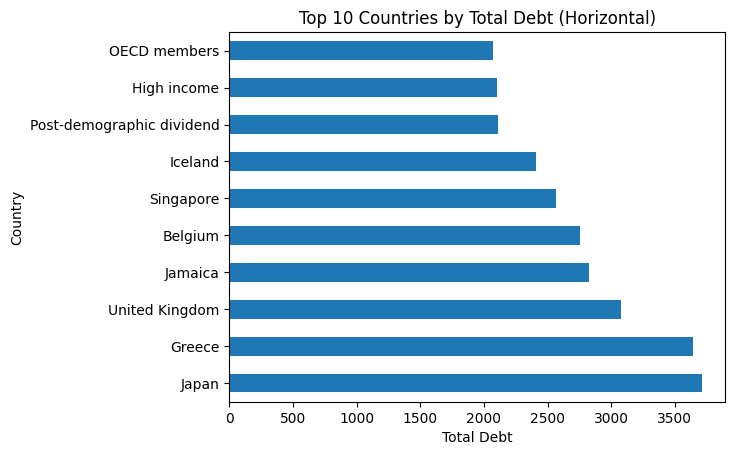

In [10]:
top_countries.head(10).plot(kind='barh')

plt.title("Top 10 Countries by Total Debt (Horizontal)")
plt.xlabel("Total Debt")
plt.ylabel("Country")

plt.show()


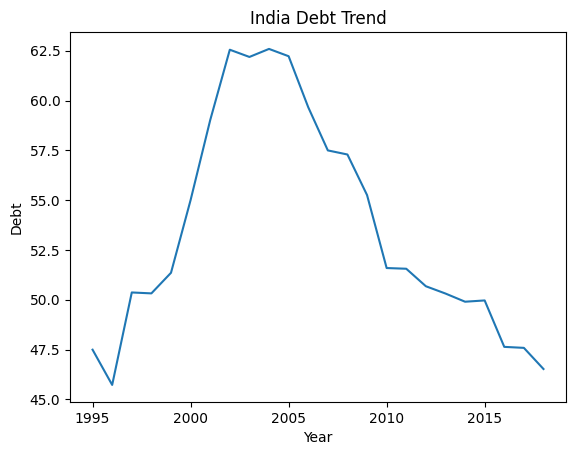

In [11]:
india = df_long[df_long["Country Name"] == "India"]

plt.plot(india["Year"], india["Debt"])

plt.title("India Debt Trend")
plt.xlabel("Year")
plt.ylabel("Debt")

plt.show()


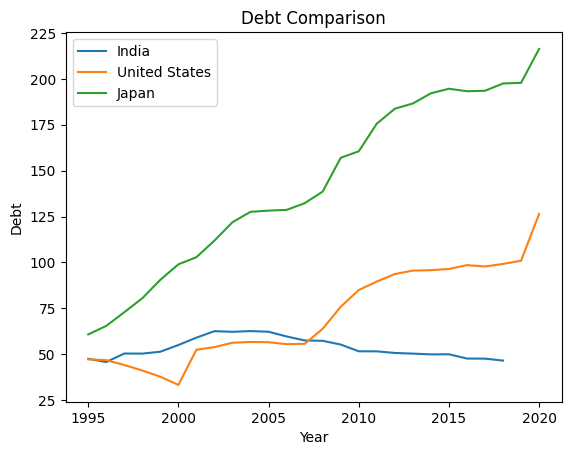

In [16]:
countries = ["India", "United States", "Japan"]

for country in countries:
    data = df_long[df_long["Country Name"] == country]
    plt.plot(data["Year"], data["Debt"], label=country)

plt.legend()
plt.title("Debt Comparison")
plt.xlabel("Year")
plt.ylabel("Debt")

plt.show()
